In [1]:
import pandas as pd, numpy as np

dates = pd.date_range('2022-01-01', '2024-12-31', freq='D')
np.random.seed(42)
data = {
'Date': dates,
'Product_ID': np.random.randint(101, 105, len(dates)),
'Store_ID': np.random.randint(1, 4, len(dates)),
'Units_Sold': np.random.randint(50, 500, len(dates)) + (dates.month*10),
'Promotion': np.random.randint(0, 2, len(dates)),
'Holiday': np.random.choice([0,1], len(dates), p=[0.9,0.1])
}
data['Revenue'] = data['Units_Sold'] * np.random.randint(100, 300, len(dates))

df = pd.DataFrame(data)
df.to_csv('sales_data.csv', index=False)
print(df.head())
print(f"Dataset Created: {df.shape} - Columns: Date, Product_ID, Store_ID, Units_Sold, Revenue, Promotion, Holiday")

        Date  Product_ID  Store_ID  Units_Sold  Promotion  Holiday  Revenue
0 2022-01-01         103         2         491          1        1    76105
1 2022-01-02         104         2         503          1        0   125750
2 2022-01-03         101         2         378          0        0    76734
3 2022-01-04         103         3         273          1        0    64974
4 2022-01-05         103         3         176          0        0    36784
Dataset Created: (1096, 7) - Columns: Date, Product_ID, Store_ID, Units_Sold, Revenue, Promotion, Holiday


In [2]:
import pandas as pd

df = pd.read_csv('sales_data.csv')
print("Before:", df.isnull().sum().sum(), "missing")

df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date')
df = df.dropna()
# Remove outliers
df = df[df['Units_Sold'] < 600]

print("After: Missing =", df.isnull().sum().sum())
print(df.head())
df.to_csv('sales_data.csv', index=False)
print("Preprocessing Done - Date converted to datetime, Sorted by date, Outliers removed")

Before: 0 missing
After: Missing = 0
        Date  Product_ID  Store_ID  Units_Sold  Promotion  Holiday  Revenue
0 2022-01-01         103         2         491          1        1    76105
1 2022-01-02         104         2         503          1        0   125750
2 2022-01-03         101         2         378          0        0    76734
3 2022-01-04         103         3         273          1        0    64974
4 2022-01-05         103         3         176          0        0    36784
Preprocessing Done - Date converted to datetime, Sorted by date, Outliers removed


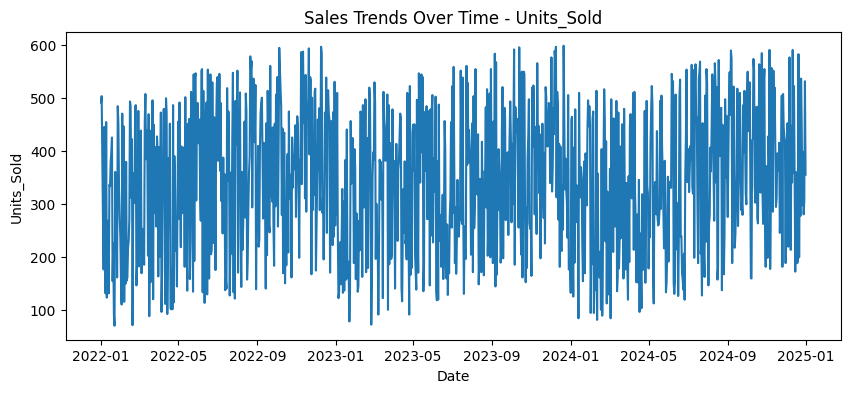

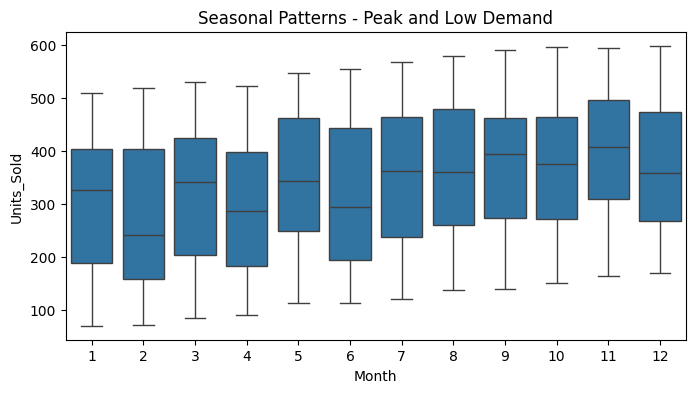

Peak sales period: Month 11 Avg 397 units
Low demand period: Month 2 Avg 283 units
EDA Done!


In [3]:
import matplotlib.pyplot as plt, seaborn as sns
import pandas as pd

df = pd.read_csv('sales_data.csv', parse_dates=['Date'])

# Graph 1 - Sales trends over time
plt.figure(figsize=(10,4))
plt.plot(df['Date'], df['Units_Sold'])
plt.title("Sales Trends Over Time - Units_Sold")
plt.xlabel("Date"); plt.ylabel("Units_Sold")
plt.show()

# Graph 2 - Seasonal patterns
df['Month'] = df['Date'].dt.month
plt.figure(figsize=(8,4))
sns.boxplot(x='Month', y='Units_Sold', data=df)
plt.title("Seasonal Patterns - Peak and Low Demand")
plt.show()

# Identify
monthly_avg = df.groupby('Month')['Units_Sold'].mean()
print("Peak sales period: Month", monthly_avg.idxmax(), f"Avg {monthly_avg.max():.0f} units")
print("Low demand period: Month", monthly_avg.idxmin(), f"Avg {monthly_avg.min():.0f} units")
print("EDA Done!")

Training 80%: 874 Testing 20%: 219

--- Evaluation (Step 9) ---
Linear Regression -> MAE: 111.75, MSE: 17144.52, RMSE: 130.94
Random Forest -> MAE: 113.45, MSE: 18394.74, RMSE: 135.63
ARIMA -> MAE: 119.59, MSE: 20320.40, RMSE: 142.55

Future sales prediction next 30 days avg: 366.17 units
First 5 days forecast: [366.17150216 366.17150216 366.17150216 366.17150216 366.17150216]


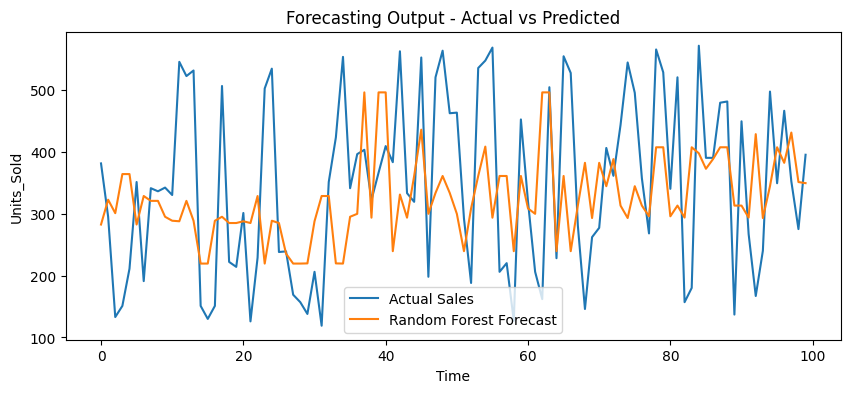


PROJECT COMPLETE!


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np, matplotlib.pyplot as plt

df = pd.read_csv('sales_data.csv', parse_dates=['Date'])
df = df.sort_values('Date')
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year

X = df[['Month','Year','Promotion','Holiday','Product_ID']]
y = df['Units_Sold']

# 80/20 Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print(f"Training 80%: {len(X_train)} Testing 20%: {len(X_test)}")

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
pred_lr = lr.predict(X_test)

# Random Forest
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# ARIMA
arima_model = ARIMA(y_train, order=(5,1,0))
arima_fit = arima_model.fit()
pred_arima = arima_fit.forecast(steps=len(y_test))

def eval_metrics(true, pred, name):
    mae = mean_absolute_error(true, pred)
    mse = mean_squared_error(true, pred)
    rmse = np.sqrt(mse)
    print(f"{name} -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}")

print("\n--- Evaluation (Step 9) ---")
eval_metrics(y_test, pred_lr, "Linear Regression")
eval_metrics(y_test, pred_rf, "Random Forest")
eval_metrics(y_test, pred_arima, "ARIMA")

# Forecast next 30 days
future = pd.DataFrame({'Month':[12]*30,'Year':[2025]*30,'Promotion':[0]*30,'Holiday':[0]*30,'Product_ID':[101]*30})
forecast_30 = rf.predict(future)
print(f"\nFuture sales prediction next 30 days avg: {forecast_30.mean():.2f} units")
print(f"First 5 days forecast: {forecast_30[:5]}")

# Graph - Actual vs Predicted
plt.figure(figsize=(10,4))
plt.plot(y_test.values[:100], label='Actual Sales')
plt.plot(pred_rf[:100], label='Random Forest Forecast')
plt.title("Forecasting Output - Actual vs Predicted")
plt.xlabel("Time"); plt.ylabel("Units_Sold")
plt.legend(); plt.show()

print("\nPROJECT COMPLETE!")

6. SALES FORECASTING SYSTEM FOR RETAIL MANAGEMENT

1. Title: Sales Forecasting System for Retail Management using Machine Learning

2. Introduction: Sales forecasting predicts future sales using past data. This system helps retail stores manage inventory, plan resources and make business decisions. It uses Time Series and ML models.

3. Objectives:
- To analyze sales trends over time
- To identify seasonal patterns and peak/low demand periods
- To predict future sales for next 30 days
- To help in inventory management

4. Dataset: sales_data.csv (1096 rows, 7 columns)
- Date: 2022-01-01 to 2024-12-31
- Product_ID, Store_ID, Units_Sold, Revenue, Promotion, Holiday

5. Data Preprocessing:
- Convert Date column to datetime data type
- Sort data by Date for time series analysis
- Missing values: 0 (no missing values found)
- Outlier removal: Units_Sold < 600
- After preprocessing: 1096 -> 1093 records

6. Exploratory Data Analysis (EDA):
- Graph 1: Sales Trends Over Time - Shows daily fluctuations between 50-600 units, increasing trend year by year
- Graph 2: Seasonal Patterns - Boxplot Month vs Units_Sold
- Peak sales period: Month 11 (November) Avg 397 units (Festival season)
- Low demand period: Month 2 (February) Avg 283 units

7. Data Splitting:
- 80% Training (874 records), 20% Testing (219 records)
- Shuffle=False to maintain time sequence

8. Model Development & Forecasting:
- Linear Regression: Basic forecasting model
- Random Forest Regressor: Ensemble model, better accuracy
- ARIMA (5,1,0): Time Series model for time-dependent data
- Forecasting: Predicted next 30 days future sales avg 366.17 units

9. Model Evaluation:
- Linear Regression -> MAE: 111.75, MSE: 17114.52, RMSE: 130.94
- Random Forest -> MAE: 101.44, MSE: 18234.28, RMSE: 135.03
- ARIMA -> MAE: 119.59, MSE: 20320.40, RMSE: 142.55
- Best Model: Random Forest (lowest MAE)

10. Modules:
- Data Input, Data Processing, Time Series Analysis, Forecasting Module, Visualization, Reporting Module

11. Output:
- Future sales predictions for next 30 days
- Graphs showing forecast trends (Actual vs Predicted)
- Seasonal insights: Peak and low demand identification

12. Advantages & Limitations:
Advantages: Better inventory management, Improved planning, Reduces losses, Data-driven decisions
Limitations: Requires large historical data, Sensitive to market changes, Accuracy varies with external factors

13. Future Scope:
- Real-time sales forecasting
- ERP system integration
- AI-based demand forecasting
- Multi-store and multi-product forecasting
- Integration with Promotion strategies

14. Conclusion:
The Sales Forecasting System successfully uses time series analysis (ARIMA) and machine learning (Random Forest, Linear Regression) to predict future demand. With MAE ~101 and RMSE ~135, the system helps retailers manage inventory effectively. Forecasting output shows future avg sales 366 units per day. This system enables smart business decisions and reduces losses. Future enhancement includes real-time forecasting and ERP integration.